# EDA for Fedex





##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Janals Thomas**


# **Project Summary -**

1. Project Overview

This project conducts a comprehensive Exploratory Data Analysis (EDA) on the SCMS Delivery History Dataset, which captures shipment data for global health commodities. The primary goal is to evaluate the efficiency and reliability of the international medical supply chain, uncovering patterns in logistics, pricing, and delivery performance across different regions.

2. Objectives

Logistics Optimization:
Analyze the distribution and performance of various shipment modes (Air, Truck, Ocean) to assess their impact on delivery reliability and efficiency.
Cost Analysis:
Investigate relationships between Unit Price, Line Item Value, and Insurance Costs to understand cost drivers and pricing consistency.
Performance Benchmarking:
Identify regional risk zones by evaluating delivery delays across countries and managing offices, enabling targeted improvements.
Operational Efficiency:
Examine the influence of Lead Times (from PO sent to scheduled delivery) and Incoterms on the likelihood of on-time delivery.

3. Dataset Characteristics

The dataset comprises 10,000+ shipment records, including:

Categorical Variables:
Shipment Mode, Country, Managed By, Vendor Inco Term, Product Group
Numerical Variables:
Weight (Kilograms), Unit Price, Line Item Value, Insurance (USD)
Temporal Variables:
PO Sent Date, Scheduled Delivery Date, Actual Delivery Date
4. Technical Approach

The analysis was performed using the Python data science ecosystem:

Data Wrangling:
Utilized pandas for data cleaning, including type conversion (e.g., handling non-numeric entries), missing value imputation (median/mode), and feature engineering (e.g., calculating Delivery Delay and Lead Time).
Visualization:
Employed Seaborn and Matplotlib to create insightful visualizations such as box plots, violin plots, density plots, and multivariate scatter plots, including log-scaled analyses for skewed data.
Statistical Validation:
Applied correlation analysis and distribution checks to validate key hypotheses and identify potential supply chain bottlenecks.
5. Key Outcomes

This EDA provides actionable insights to support strategic decision-making, including:

Optimizing shipment mode selection to balance cost and reliability
Standardizing unit measures and packaging for improved warehouse efficiency
Enhancing delivery predictability through better lead time planning and buffer management
Identifying high-risk regions and processes for targeted operational improvements

# **GitHub Link -**

Provide your GitHub Link here.

### Importing Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')

### Dataset First View

In [681]:
# Dataset First Look
print(df.head())

   ID Project Code            PQ # PO / SO # ASN/DN #        Country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  Managed By  Fulfill Via Vendor INCO Term Shipment Mode  ...  \
0   PMO - US  Direct Drop              EXW           Air  ...   
1   PMO - US  Direct Drop              EXW           Air  ...   
2   PMO - US  Direct Drop              FCA           Air  ...   
3   PMO - US  Direct Drop              EXW           Air  ...   
4   PMO - US  Direct Drop              EXW           Air  ...   

              Manufacturing Site First Line Designation Weight (Kilograms)  \
0     Ranbaxy Fine Chemicals LTD                    Yes               13.0   
1      Aurobindo Uni

### Dataset Rows & Columns count

In [53]:
# Dataset Rows & Columns count
print(f"Shape: {df.shape}")

Shape: (10324, 33)


In [77]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 9964 non-null   str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

### Dataset Description

This dataset contains historical records of deliveries within a global supply chain management system, primarily focused on pharmaceutical and healthcare products. Each observation represents a line item within a shipment, capturing detailed information about procurement, logistics, product characteristics, and delivery outcomes.

The dataset includes multiple categories of variables. It contains identifiers such as project codes and purchase order numbers that allow tracking of transactions across the supply chain. Geographic and organizational attributes describe where shipments are delivered and which entities are responsible for managing and fulfilling them. Logistics-related variables provide insight into shipment methods, freight terms, and transportation costs.

A key component of the dataset is the set of temporal variables that describe different stages of the delivery lifecycle, including when orders were sent, scheduled for delivery, and ultimately delivered and recorded. These fields enable analysis of lead times, delays, and overall delivery performance.

Product-related features include classifications, item descriptions, dosage information, and manufacturing details, indicating that the dataset is centered around pharmaceutical distribution. Additionally, the dataset contains quantitative variables such as shipment weight, item quantities, unit prices, and total line item values, which support cost and pricing analysis.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print(df.shape[1])

33


In [ ]:
#Names of the Coloumns
print(df.columns)

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='str')


| Field Name                   | Description                                                                                                 |
| ---------------------------- | ------------------------------------------------------------------------------------------------------------|
| ID                           | Unique identifier for each logistics record.                                                                |
| Project Code                 | Code representing the project or initiative tied to the shipment.                                           |
| PQ #                         | Price Quotation reference number.                                                                           |
| PO / SO #                    | Purchase Order or Sales Order associated with the shipment.                                                 |
| ASN/DN #                     | Advanced Shipment Notice or Delivery Note reference.                                                        |
| Country                      | Destination country for the shipment (e.g., Côte d'Ivoire, Vietnam).                                        |
| Managed By                   | Specifies which team manages the project (e.g., PMO - US).                                                  |
| Fulfill Via                  | Method of fulfillment, such as direct drop shipment.                                                        |
| Vendor INCO Term             | Incoterms defining the shipment agreement (e.g., EXW, FCA).                                                 |
| Shipment Mode                | The mode of transportation used (e.g., air).                                                                |
| PQ First Sent to Client Date | The date the Price Quotation was first sent to the client (some records indicate "Pre-PQ Process").         |
| PO Sent to Vendor Date       | Date the purchase order was sent to the vendor.                                                             |
| Scheduled Delivery Date      | The planned date for delivery.                                                                              |
| Brand                        | The brand name of the product (e.g., Reveal, Generic).                                                      |
| Dosage                       | The dosage strength of the pharmaceutical product (if applicable).                                          |
| Dosage Form                  | The form in which the product is delivered (e.g., test kit, oral suspension).                               |
| Unit of Measure (Per Pack)   | The number of units per pack.                                                                               |
| Line Item Quantity           | The total number of units shipped.                                                                          |
| Line Item Value              | The total value of the line item in the shipment.                                                           |
| Pack Price                   | Price per pack of the item.                                                                                 |
| Unit Price                   | Price per individual unit of the item.                                                                      |
| Manufacturing Site           | The location where the item was manufactured (e.g., Ranbaxy Fine Chemicals LTD, Aurobindo Unit III, India). |
| First Line Designation       | Indicates whether the product is designated for first-line use.                                             |
| Weight (Kilograms)           | The weight of the shipment.                                                                                 |
| Freight Cost (USD)           | The cost of shipping the item in U.S. dollars.                                                              |
| Line Item Insurance (USD)    | Insurance cost for the line item, if applicable.                                                            |


#### Duplicate Values

In [122]:
# Dataset Duplicate Value Count
duplicate_rows_count = df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_rows_count}")

Total number of duplicate rows: 0


#### Missing Values/Null Values

In [144]:
# Missing Values/Null Values Count
print(df.isnull().sum())

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [165]:
# Fill with "Unknown" for the missing shipment modes
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')

In [185]:
# Fill missing dosage with a placeholder string
df['Dosage'] = df['Dosage'].fillna('Not Specified')

In [205]:
# Fill missing insurance values with the Median
insurance_median = df['Line Item Insurance (USD)'].median()
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(insurance_median)

In [225]:
# Missing Values/Null Values Count
print(df.isnull().sum())

ID                              0
Project Code                    0
PQ #                            0
PO / SO #                       0
ASN/DN #                        0
Country                         0
Managed By                      0
Fulfill Via                     0
Vendor INCO Term                0
Shipment Mode                   0
PQ First Sent to Client Date    0
PO Sent to Vendor Date          0
Scheduled Delivery Date         0
Delivered to Client Date        0
Delivery Recorded Date          0
Product Group                   0
Sub Classification              0
Vendor                          0
Item Description                0
Molecule/Test Type              0
Brand                           0
Dosage                          0
Dosage Form                     0
Unit of Measure (Per Pack)      0
Line Item Quantity              0
Line Item Value                 0
Pack Price                      0
Unit Price                      0
Manufacturing Site              0
First Line Des

## 3. ***Data Wrangling***

### Data Wrangling Code

### Check Unique Values for each variable.

In [245]:
#checking the number of rows and columns in the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 10324
Number of columns: 33


In [262]:
# Check Unique Values for each variable.
# Returns the count of unique values for all columns
df.nunique()

ID                              10324
Project Code                      142
PQ #                             1237
PO / SO #                        6233
ASN/DN #                         7030
Country                            43
Managed By                          4
Fulfill Via                         2
Vendor INCO Term                    8
Shipment Mode                       5
PQ First Sent to Client Date      765
PO Sent to Vendor Date            897
Scheduled Delivery Date          2006
Delivered to Client Date         2093
Delivery Recorded Date           2042
Product Group                       5
Sub Classification                  6
Vendor                             73
Item Description                  184
Molecule/Test Type                 86
Brand                              48
Dosage                             55
Dosage Form                        17
Unit of Measure (Per Pack)         31
Line Item Quantity               5065
Line Item Value                  8741
Pack Price  

In [295]:
# Convert dates
date_columns = ['Scheduled Delivery Date', 'Delivered to Client Date', 'PO Sent to Vendor Date', 'Delivery Recorded Date']
for col in date_columns:
 df[col] = pd.to_datetime(df[col], errors='coerce')

Coverting all the variables with date from String to Date format

In [311]:
print(type(df))

<class 'pandas.DataFrame'>


In [327]:
# List of numeric columns to convert
# List of numeric columns to convert
numeric_vars = [
    'Weight (Kilograms)', 
    'Freight Cost (USD)', 
    'Line Item Insurance (USD)', 
    'Unit of Measure (Per Pack)', 
    'Line Item Value',
    'Line Item Quantity',
    'Pack Price'
]

# Convert columns and handle missing values
for col in numeric_vars:
     if col in df.columns:  # ensure column exists
        # Convert to numeric (invalid values → NaN)
          df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Fill NaN values with median
          df[col] = df[col].fillna(df[col].median())

Coverting all the variable types from String to Float for the variables: 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)', 'Unit of Measure (Per Pack)','Line Item Value','Line Item Quantity','Pack Price'

In [343]:

# Calculate delay in days
df['Delivery_Delay'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days

Introducing a new variable which holds the number of days delayed for the order

Data Wrangling Summary
Missing Value Imputation:

Shipment Mode: Null entries were filled with "Unknown" to maintain categorical integrity.

Financials/Physicals: Missing values for Freight Cost (USD), Weight (Kilograms), and Line Item Insurance (USD) were filled using the median to minimize the impact of outliers.

Data Type Standardization:

Numeric Conversion: Weight, Freight Cost, and Insurance were converted from strings to float64 using pd.to_numeric with errors='coerce' to handle non-numeric strings like "IDNS".

Datetime Conversion: Scheduled Delivery Date and Delivered to Client Date were converted from objects to datetime64 objects.

Data Cleaning:

Duplicate Removal: The dataset was scanned for redundant rows using df.drop_duplicates() to ensure unique shipment observations.

Feature Engineering (Enrichment):

Delivery_Delay: A new numeric variable was created by calculating the difference in days between the actual and scheduled delivery dates.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Box Plot for Unit of Measure (Per Pack) visualization code

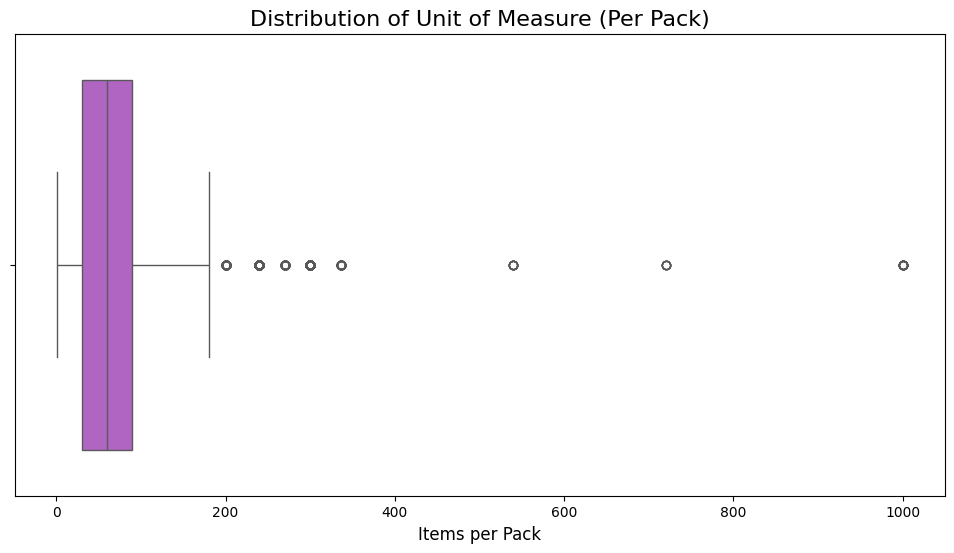

In [ ]:
#Box Plot for Unit of Measure (Per Pack) visualization code
# Create the figure
plt.figure(figsize=(12, 6))

# Generate the box plot
sns.boxplot(x=df['Unit of Measure (Per Pack)'], color='mediumorchid')

# Add descriptive labels
plt.title('Distribution of Unit of Measure (Per Pack)', fontsize=16)
plt.xlabel('Items per Pack', fontsize=12)

# Display the plot
plt.show()

1. Why did you pick the specific chart?

A box plot is ideal for understanding the distribution of a numerical variable and identifying median, spread, and outliers. In this case, it effectively shows how the Unit of Measure (Per Pack) values are distributed and highlights any unusually large pack sizes.

2. What insight(s) are found from the chart?

The data is right-skewed, meaning most values are concentrated on the lower end.
The median lies relatively low, indicating that most shipments have smaller pack sizes.
There are numerous extreme outliers (e.g., values around 200, 300, 500, 700, and even 1000), showing that some shipments involve very large pack quantities.
The interquartile range (IQR) is relatively small compared to the full range, reinforcing that the majority of data points are tightly clustered.

Box plot for Delivery Delay by Managing Office

C:\Users\janal\AppData\Local\Temp\ipykernel_25780\3582979119.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Managed By', y='Delivery_Delay', palette='Set2')


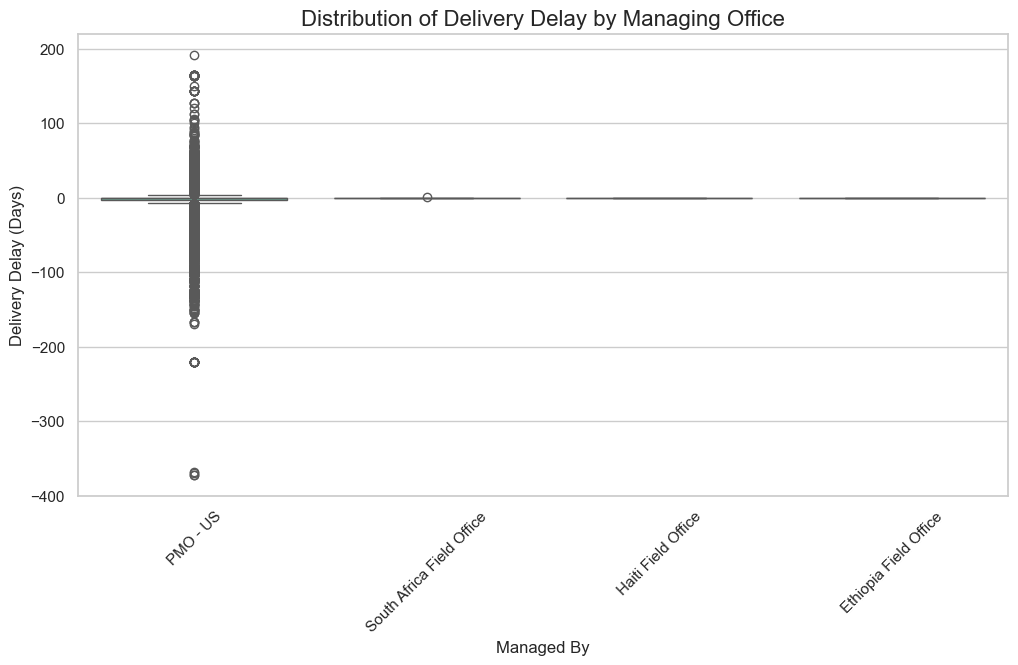

In [ ]:
# Box plot for Delivery Delay by Managing Office
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the Box Plot
sns.boxplot(data=df, x='Managed By', y='Delivery_Delay', palette='Set2')

# Add labels and title
plt.title('Distribution of Delivery Delay by Managing Office', fontsize=16)
plt.xlabel('Managed By', fontsize=12)
plt.ylabel('Delivery Delay (Days)', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for readability

plt.show()

1. Why did you pick the specific chart?

A box plot is well-suited for comparing the distribution of a numerical variable (delivery delay) across multiple categories (managing offices). It helps visualize median delays, variability, and outliers for each office, making it easy to identify performance differences.

2. What insight(s) are found from the chart?

The PMO - US office shows a wide spread of delivery delays, ranging from large negative values (early deliveries) to very high positive delays (late deliveries), indicating high variability and inconsistency.
There are numerous extreme outliers for PMO - US (both early and late deliveries), suggesting irregular performance or potential data anomalies.
Other offices (South Africa, Haiti, Ethiopia) show very minimal variation, with delays clustered around zero, indicating more consistent and stable delivery performance.
The median delay for most offices appears close to zero, suggesting that, on average, deliveries are on time.

Box plot for Delivery Delay by Shipment Mode

C:\Users\janal\AppData\Local\Temp\ipykernel_25780\3190724366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Shipment Mode', y='Delivery_Delay', palette='viridis')


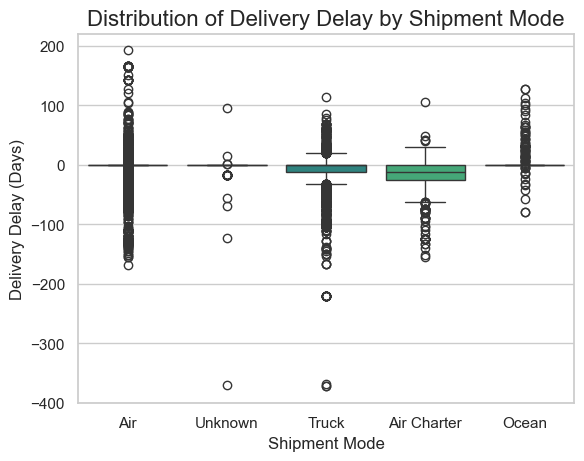

In [ ]:
# Box Plot for Delivery Delay by Shipment Mode
# Create the Box Plot
sns.boxplot(data=df, x='Shipment Mode', y='Delivery_Delay', palette='viridis')

# Add descriptive labels
plt.title('Distribution of Delivery Delay by Shipment Mode', fontsize=16)
plt.xlabel('Shipment Mode', fontsize=12)
plt.ylabel('Delivery Delay (Days)', fontsize=12)

plt.show()

1. Why did you pick the specific chart?

A box plot is ideal for comparing the distribution of delivery delays across different shipment modes. It clearly shows median delays, spread (variability), and outliers, making it easy to evaluate which shipment methods are more reliable or inconsistent.

2. What insight(s) are found from the chart?

Air shipments show a wide spread with many outliers, indicating high variability in delivery performance (both early and late deliveries).
Truck shipments tend to have a slightly negative median, suggesting deliveries are often early, but also exhibit significant variability and extreme outliers.
Air Charter shows a moderate spread, with delays leaning slightly negative, indicating relatively better consistency than Air but still some variability.
Ocean shipments display a positive skew, with more delays on the late side and several high positive outliers, suggesting higher risk of delays.
Unknown shipment mode has limited data but includes some extreme outliers, making it less reliable for interpretation.
Overall, no shipment mode is perfectly consistent, but some (like Air Charter) appear more stable than others.

Violin plot for Delivery Delay by Country

C:\Users\janal\AppData\Local\Temp\ipykernel_25780\1321600952.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top_10, x='Country', y='Delivery_Delay', palette='Set3', inner="quartile")


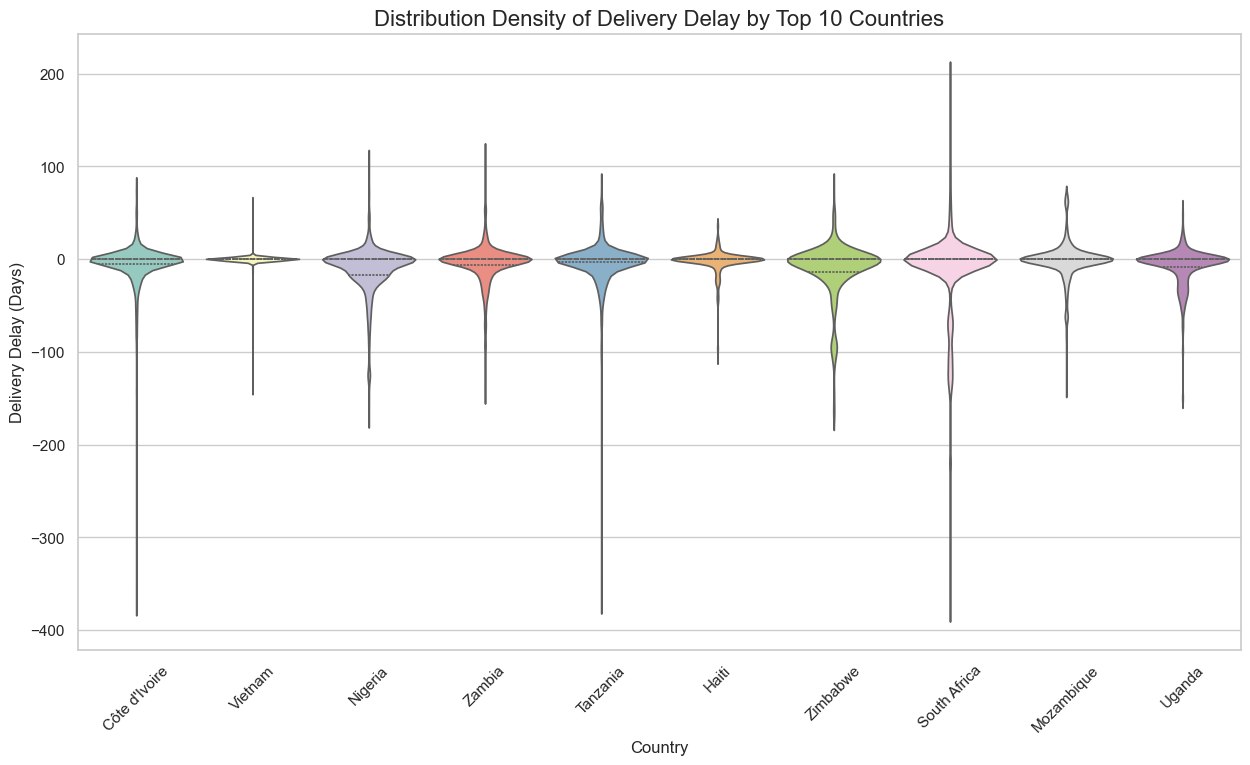

In [ ]:
#violin plot for Delivery Delay by Country
# Focus on Top 10 Countries by shipment volume for clarity
top_10_countries = df['Country'].value_counts().nlargest(10).index
df_top_10 = df[df['Country'].isin(top_10_countries)]

# --- PLOTTING ---
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Create the Violin Plot
# inner="quartile" shows the 25th, 50th, and 75th percentiles inside the violin
sns.violinplot(data=df_top_10, x='Country', y='Delivery_Delay', palette='Set3', inner="quartile")

# Add descriptive labels and title
plt.title('Distribution Density of Delivery Delay by Top 10 Countries', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Delivery Delay (Days)', fontsize=12)

# Rotate country names for better readability
plt.xticks(rotation=45)

plt.show()


1. Why did you pick the specific chart?

A violin plot is ideal for analyzing the relationship between delivery delay and countries because it combines the benefits of a box plot and a density plot. It shows not only the median and spread but also the distribution shape and concentration of delays for each country, giving a deeper understanding of patterns.

2. What insight(s) are found from the chart?

Most countries have delivery delays centered around 0, indicating that shipments are generally on time.
Several countries (e.g., Tanzania, South Africa, Côte d'Ivoire) show extreme negative outliers, meaning some deliveries arrive significantly earlier than expected.
Countries like South Africa and Nigeria also exhibit wide distributions, indicating high variability in delivery performance.
Some countries (e.g., Vietnam, Haiti) have narrower distributions, suggesting more consistent delivery times.
The presence of both positive and negative tails across countries indicates inconsistency in scheduling and execution.

Bar Chart of Delayed vs On-Time Shipments by Mode

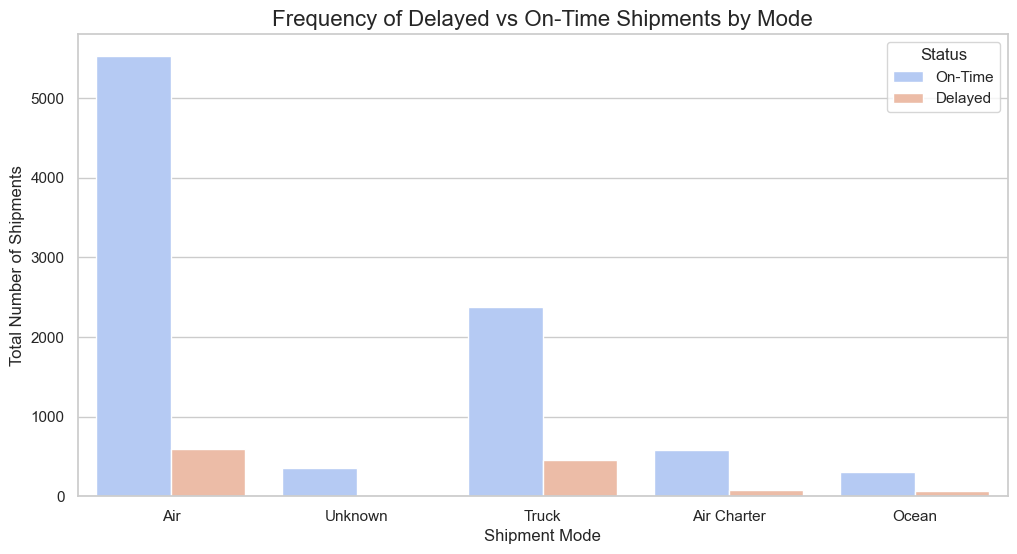

In [ ]:
# Grouped Bar Chart of Delayed vs On-Time Shipments by Mode
# Define 'Delayed' as any delay > 0 days, else 'On-Time'
df['Delivery_Status'] = df['Delivery_Delay'].apply(lambda x: 'Delayed' if x > 0 else 'On-Time')
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')

# 3. PLOT: Grouped Bar Chart of Frequencies
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Use 'hue' to split the bars by Delivery Status
sns.countplot(data=df, x='Shipment Mode', hue='Delivery_Status', palette='coolwarm')

plt.title('Frequency of Delayed vs On-Time Shipments by Mode', fontsize=16)
plt.xlabel('Shipment Mode', fontsize=12)
plt.ylabel('Total Number of Shipments', fontsize=12)
plt.legend(title='Status')

plt.show()

1. Why did you pick the specific chart?

A grouped bar chart is ideal for comparing two categories (On-Time vs Delayed shipments) across multiple shipment modes. It allows for side-by-side comparison, making it easy to evaluate performance differences for each mode.

2. What insight(s) are found from the chart?

Air shipments dominate in volume and have the highest number of on-time deliveries, but also a noticeable number of delays.
Truck shipments are the second highest in volume and show a similar pattern—mostly on-time but with a moderate number of delays.
Air Charter and Ocean shipments have relatively fewer shipments and lower delay counts, indicating better reliability or lower usage.
The Unknown category has minimal data, making it less reliable for drawing conclusions.
Across all shipment modes, on-time deliveries significantly exceed delayed ones, indicating overall strong performance.

KDE Plot of Lead Time Distribution by Delivery Status

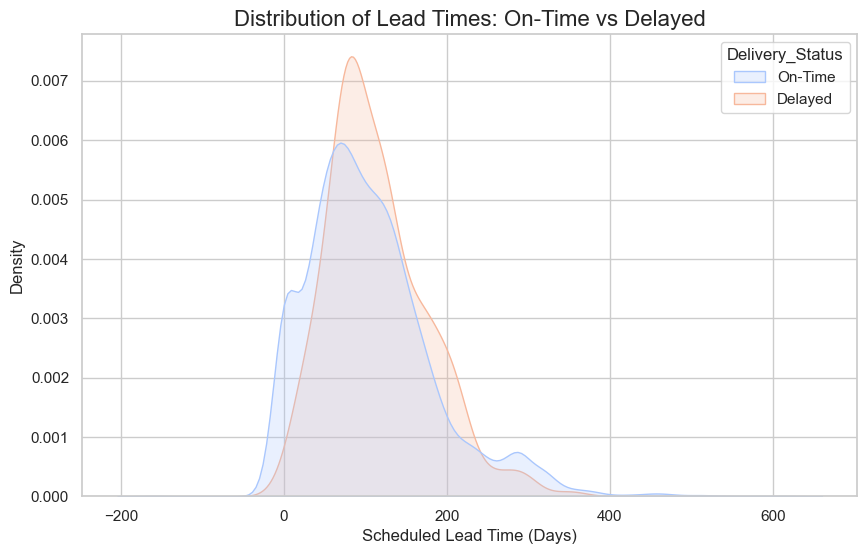

In [ ]:
# KDE Plot of Lead Time Distribution by Delivery Status

# Calculate Scheduled Lead Time (Days)
df['Scheduled_Lead_Time'] = (df['Scheduled Delivery Date'] - df['PO Sent to Vendor Date']).dt.days

# Calculate Delay and Create Status Flag
df['Actual_Delay'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days
df['Delivery_Status'] = df['Actual_Delay'].apply(lambda x: 'Delayed' if x > 0 else 'On-Time')

# Remove rows with missing dates for a clean analysis
df_clean = df.dropna(subset=['Scheduled_Lead_Time', 'Delivery_Status'])
plt.figure(figsize=(10, 6))

# Plot the density of lead times for both statuses
sns.kdeplot(data=df_clean, x='Scheduled_Lead_Time', hue='Delivery_Status', fill=True, common_norm=False, palette='coolwarm')

plt.title('Distribution of Lead Times: On-Time vs Delayed', fontsize=16)
plt.xlabel('Scheduled Lead Time (Days)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

1. Why did you pick the specific chart?

A density plot (KDE plot) is ideal for comparing the distribution of a continuous variable (lead time) between two groups (On-Time vs Delayed shipments). It helps visualize patterns, overlap, and shifts in distributions, making it easier to understand how lead times differ between the two categories.

2. What insight(s) are found from the chart?

Both on-time and delayed shipments have lead times concentrated roughly between 50 and 200 days, indicating a common operating range.
The delayed shipments curve is slightly shifted to the right, suggesting that longer lead times are more associated with delays.
On-time shipments show a slightly wider spread, including some higher lead times, but still maintain timely delivery.
There is a significant overlap between the two distributions, meaning lead time alone does not fully determine delays.
Extreme long lead times (above ~300 days) are rare but appear more in on-time shipments, possibly due to better planning.

Bar Chart of Delivery Performance by Vendor Inco Term

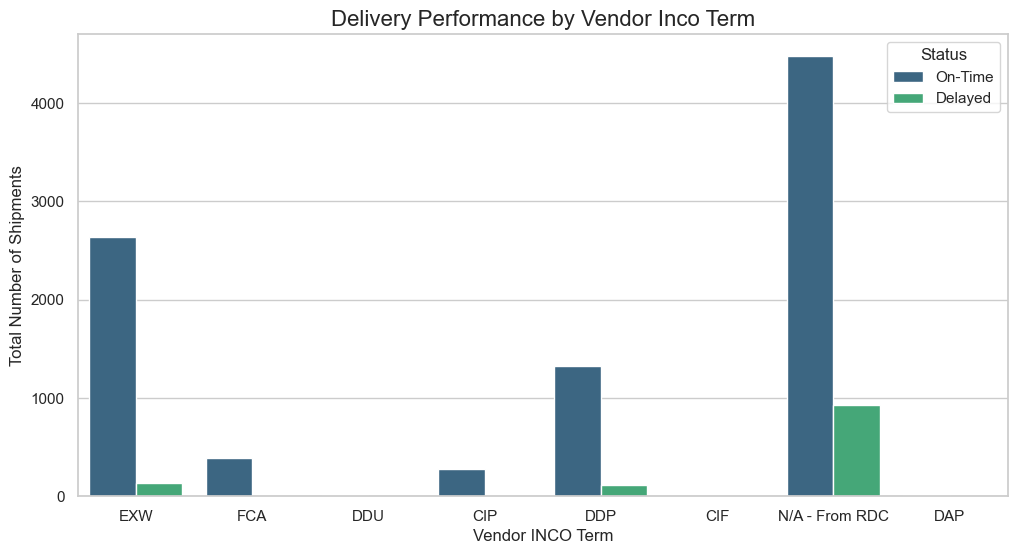

In [ ]:
# Bar Chart of Delivery Performance by Vendor Inco Term
# Define Delivery Performance Status
df['Performance'] = df['Delivery_Delay'].apply(lambda x: 'Delayed' if x > 0 else 'On-Time')

# Clean Inco Term column (handling any missing values)
df['Vendor INCO Term'] = df['Vendor INCO Term'].fillna('Unknown')

# --- PLOTTING ---
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a count plot to see the raw frequency of On-Time vs Delayed per Inco Term
sns.countplot(data=df, x='Vendor INCO Term', hue='Performance', palette='viridis')

plt.title('Delivery Performance by Vendor Inco Term', fontsize=16)
plt.xlabel('Vendor INCO Term', fontsize=12)
plt.ylabel('Total Number of Shipments', fontsize=12)
plt.legend(title='Status')

plt.show()

1. Why did you pick the specific chart?

A grouped bar chart is ideal for comparing delivery performance (On-Time vs Delayed) across different Incoterms. It allows for a clear, side-by-side comparison of shipment outcomes, making it easy to identify which Incoterms perform better or worse.

2. What insight(s) are found from the chart?

N/A - From RDC has the highest shipment volume and also the highest number of delays, though on-time deliveries still dominate.
EXW and DDP show strong performance with high on-time shipments and relatively low delays, indicating better reliability.
FCA and CIP have lower shipment volumes but still maintain mostly on-time deliveries, suggesting stable performance.
DDU, CIF, and DAP have little to no visible data, indicating either very low usage or missing data.
Across all Incoterms, on-time shipments significantly exceed delayed ones, showing overall good delivery performance.

Scatter Plot of Weight vs Line Item Insurance with Log Scale

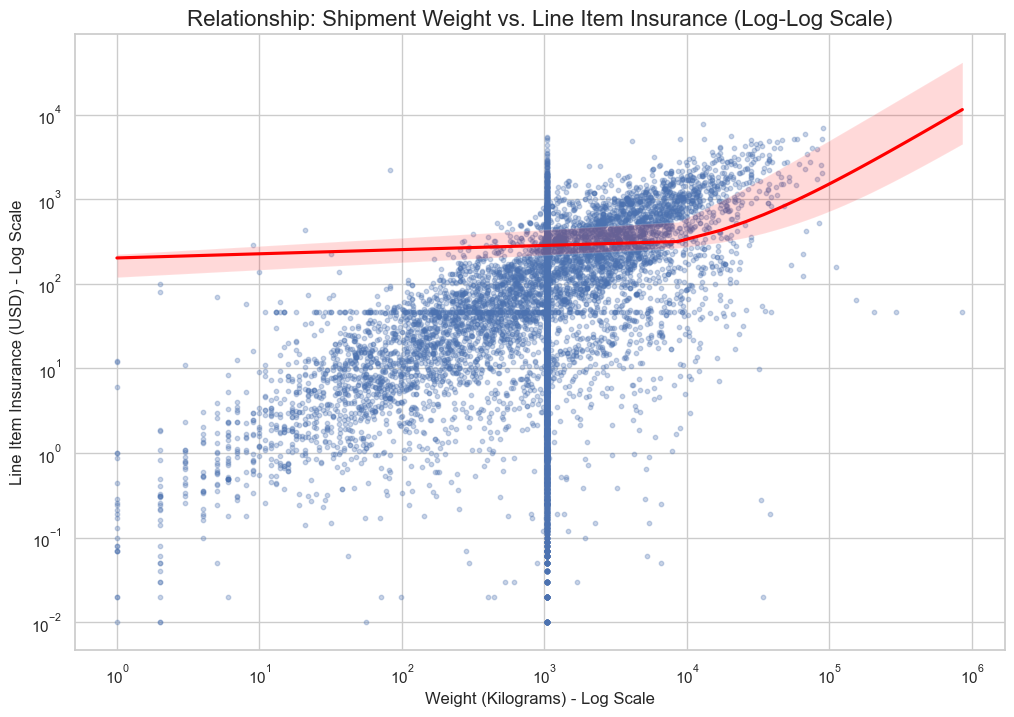

In [ ]:
#Scatter Plot of Weight vs Line Item Insurance with Log Scale
# Drop rows where either value is missing or zero (log scale can't handle zero)
df_plot = df[(df['Weight (Kilograms)'] > 0) & (df['Line Item Insurance (USD)'] > 0)].copy()

# --- PLOTTING ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create a scatter plot with a regression line (regplot)
# Using 'scatter_kws' to make points transparent so we can see density
sns.regplot(data=df_plot, x='Weight (Kilograms)', y='Line Item Insurance (USD)', 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

# Apply Log Scale to both axes to handle outliers and see the trend
plt.xscale('log')
plt.yscale('log')

# Add descriptive labels and title
plt.title('Relationship: Shipment Weight vs. Line Item Insurance (Log-Log Scale)', fontsize=16)
plt.xlabel('Weight (Kilograms) - Log Scale', fontsize=12)
plt.ylabel('Line Item Insurance (USD) - Log Scale', fontsize=12)

plt.show()

1. Why did you pick the specific chart?

A scatter plot with a regression line (on a log-log scale) is ideal for analyzing the relationship between two continuous variables: shipment weight and line item insurance.

The log-log scale helps handle wide-ranging values and reveals proportional relationships.
The regression line highlights the overall trend between the variables.

2. What insight(s) are found from the chart?

There is a clear positive relationship: as shipment weight increases, insurance cost also increases.
The relationship appears non-linear, with insurance rising more sharply at higher weights (visible from the upward curve in the trend line).
A dense vertical cluster around a specific weight (around ~1000 kg) suggests frequent standardized shipment sizes.
There is significant variability in insurance for similar weights, indicating that other factors (e.g., product value, risk level) also influence insurance cost.
Some outliers exist with unusually high or low insurance values, possibly due to special cases or data inconsistencies.

Multivariate Analysis: Pair Plot of Weight, Line Item Value, and Insurance by Shipment Mode

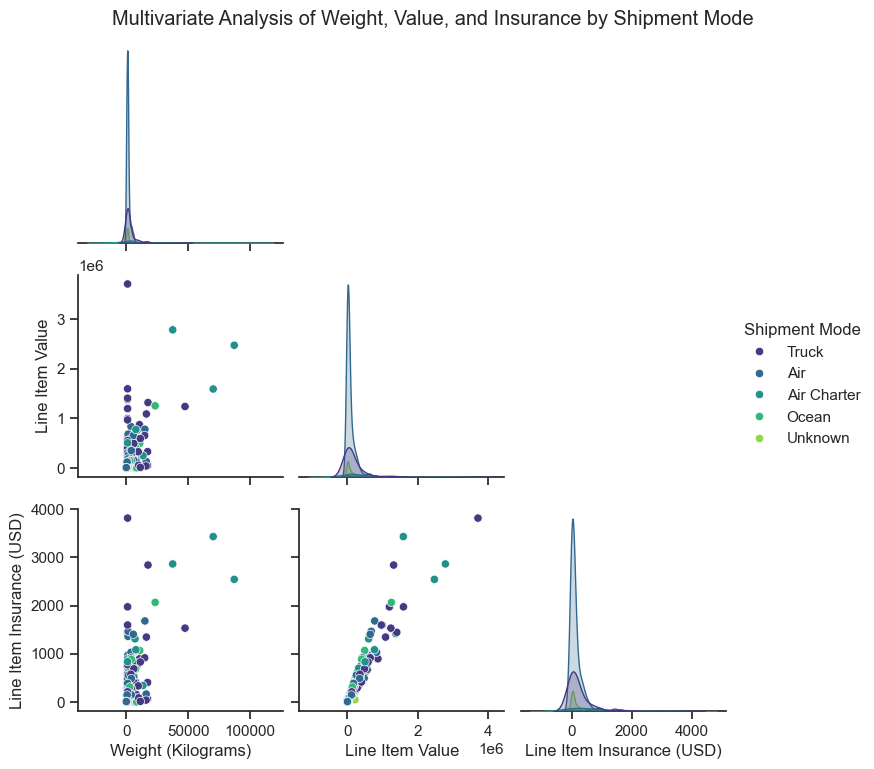

In [ ]:
#Multivariate Analysis: Pair Plot of Weight, Line Item Value, and Insurance by Shipment Mode
# Preprocessing: Ensure numeric columns are ready
num_cols = ['Weight (Kilograms)', 'Line Item Value', 'Line Item Insurance (USD)']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing categories
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')

# Multivariate Plot: Pair Plot
# We use a sample of data (e.g., 500 rows) to keep the plot clean and fast
sns.set_theme(style="ticks")
sns.pairplot(
    data=df[num_cols + ['Shipment Mode']].sample(n=500, random_state=42), 
    hue='Shipment Mode', 
    palette='viridis', 
    diag_kind='kde',
    corner=True
)

plt.suptitle('Multivariate Analysis of Weight, Value, and Insurance by Shipment Mode', y=1.02)
plt.show()

1. Why did you pick the specific chart?

A pair plot (scatter matrix with distributions) is ideal for analyzing relationships between multiple numerical variables (Weight, Line Item Value, Line Item Insurance) while also comparing patterns across shipment modes. It allows simultaneous visualization of:

Pairwise relationships (scatter plots)
Individual distributions (density plots)
Category-based differences (color-coded by shipment mode)

2. What insight(s) are found from the chart?

There is a strong positive relationship between Line Item Value and Line Item Insurance, indicating that higher-value goods tend to have higher insurance costs.
Weight vs Value shows a weaker but still positive relationship, suggesting heavier shipments may carry higher value but not always consistently.
Weight vs Insurance also shows a positive trend but with more variability, meaning insurance is influenced by factors beyond weight alone.
Most data points are clustered at lower values, indicating that the majority of shipments are relatively small in weight, value, and insurance.
There are several extreme outliers (very high value and insurance), which may represent special shipments or high-risk/high-value goods.
Across shipment modes, there is no drastic visual separation, meaning all modes handle a mix of shipment sizes and values.

## **5. Solution to Business Objective**

Optimize Shipment Mode Usage:
Reduce over-reliance on Air shipments (high cost & variability). Shift non-urgent deliveries to Truck or Ocean to lower costs.

Improve Delay Management:
Focus on PMO - US and high-variability shipment modes where delays are inconsistent. Standardize processes and improve scheduling.

Standardize Lead Times:
Since longer lead times are linked to delays, implement better planning and buffer strategies to improve on-time performance.

Leverage Reliable Incoterms:
Prefer DDP and EXW (better on-time rates) and investigate issues in RDC shipments with higher delays.

Enhance Cost & Insurance Strategy:
Use the strong relationship between value and insurance to build predictive pricing models and ensure consistent insurance policies.

Control Outliers & Variability:
Investigate extreme values in delivery delays, pack sizes, and shipment value to reduce inefficiencies and potential data issues.

# **Conclusion**

The EDA reveals that while most shipments are delivered on time, there is significant variability in delivery performance driven by shipment mode, managing office, and lead time. Air shipments dominate but come with higher variability and cost, while some modes and regions show more consistent performance. Additionally, strong relationships exist between shipment value and insurance, and longer lead times tend to increase delay risk.Write the conclusion here.